# European Dataset Experiment

## Import Libraries

In [125]:
# Import libraries

import json
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mafese import Data

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression  # Just for evaluating during feature selection
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, roc_curve

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

## Load Data and Scaling Data for Feature Selection

In [126]:
# Load Dataset
df = pd.read_csv('Credit_Card_Applications.csv')

In [127]:
df

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.460,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.000,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.750,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.500,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.170,2,6,4,1.960,1,1,14,0,2,60,159,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3252,15789865,1,18.17,2.460,2,8,7,0.960,0,1,2,1,2,160,588,0
3253,15627190,1,39.00,5.000,2,13,4,3.500,1,1,10,1,2,0,1,1
3254,15788224,1,20.00,11.045,2,8,4,2.000,0,0,0,1,2,136,1,0
3255,15702149,1,32.75,2.335,2,2,8,5.750,0,0,0,1,2,292,1,0


In [128]:
# Optional: Drop 'id' column if present
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

# Shuffle the data to mix Class 0 and Class 1
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Prepare features and labels
X = df.drop('Class', axis=1)  # Features
y = df['Class']               # Labels

# Initialize mafese Data object
data = Data(X, y)

# Split the data
# (mafese automatically splits into training and testing sets)
data.split_train_test(test_size=0.3, random_state=42, inplace=True, stratify=y)  # You can adjust test_size and seed

# Scale the features
data.X_train, scaler_X = data.scale(data.X_train, scaling_methods=("standard", "minmax"))
data.X_test = scaler_X.transform(data.X_test)

# Encode the labels
data.y_train, scaler_y = data.encode_label(data.y_train)
data.y_test = scaler_y.transform(data.y_test)

# Print data shapes
print(f"Training Features Shape: {data.X_train.shape}")
print(f"Training Labels Shape: {data.y_train.shape}")
print(f"Testing Features Shape: {data.X_test.shape}")
print(f"Testing Labels Shape: {data.y_test.shape}")

Training Features Shape: (2279, 14)
Training Labels Shape: (2279,)
Testing Features Shape: (978, 14)
Testing Labels Shape: (978,)


/Users/macbookpro/anaconda3/envs/dev/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning:

X has feature names, but StandardScaler was fitted without feature names



In [129]:
data.y_test

array([0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,

## Exploratory Data Analysis

In [130]:
# load the dataset (read the CSV file)
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,1,41.17,1.250,1,9,4,0.250,0,0,0,0,2,0,196,0
1,1,40.92,0.835,2,1,1,0.000,1,0,0,0,2,130,2,0
2,1,56.58,18.500,2,2,5,15.000,1,1,17,1,2,0,1,1
3,1,27.25,1.665,2,13,8,5.085,1,1,9,0,2,399,828,1
4,0,47.42,3.000,2,14,4,13.875,1,1,2,1,2,519,1705,1


In [131]:
# Show the dataset information, including data types and missing values
df.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
count,3257.000000,3257.000000,3257.000000,3257.000000,3257.000000,3257.000000,3257.000000,3257.000000,3257.000000,3257.000000,3257.000000,3257.000000,3257.000000,3257.000000,3257.000000
mean,0.678539,31.722640,4.789140,1.770341,7.350015,4.687135,2.292776,0.523795,0.434142,2.389929,0.464845,1.929383,183.091495,1014.507522,0.448265
std,0.467109,12.118822,4.990613,0.427917,3.688458,1.996018,3.491520,0.499510,0.495720,4.814137,0.498839,0.294168,171.169922,5324.129729,0.497393
min,0.000000,13.750000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,0.000000,22.580000,1.000000,2.000000,4.000000,4.000000,0.165000,0.000000,0.000000,0.000000,0.000000,2.000000,80.000000,1.000000,0.000000
50%,1.000000,28.670000,2.750000,2.000000,8.000000,4.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,160.000000,5.000000,0.000000
75%,1.000000,38.170000,7.500000,2.000000,10.000000,5.000000,2.750000,1.000000,1.000000,3.000000,1.000000,2.000000,268.000000,397.000000,1.000000
max,1.000000,80.250000,28.000000,3.000000,14.000000,9.000000,28.500000,1.000000,1.000000,67.000000,1.000000,3.000000,2000.000000,100001.000000,1.000000


In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3257 entries, 0 to 3256
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      3257 non-null   int64  
 1   A2      3257 non-null   float64
 2   A3      3257 non-null   float64
 3   A4      3257 non-null   int64  
 4   A5      3257 non-null   int64  
 5   A6      3257 non-null   int64  
 6   A7      3257 non-null   float64
 7   A8      3257 non-null   int64  
 8   A9      3257 non-null   int64  
 9   A10     3257 non-null   int64  
 10  A11     3257 non-null   int64  
 11  A12     3257 non-null   int64  
 12  A13     3257 non-null   int64  
 13  A14     3257 non-null   int64  
 14  Class   3257 non-null   int64  
dtypes: float64(3), int64(12)
memory usage: 381.8 KB


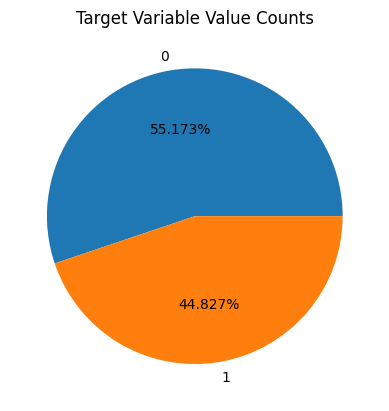

In [133]:
labels = df['Class'].unique()
sizes = df.Class.value_counts().values

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%')
ax.set_title('Target Variable Value Counts')
plt.show()

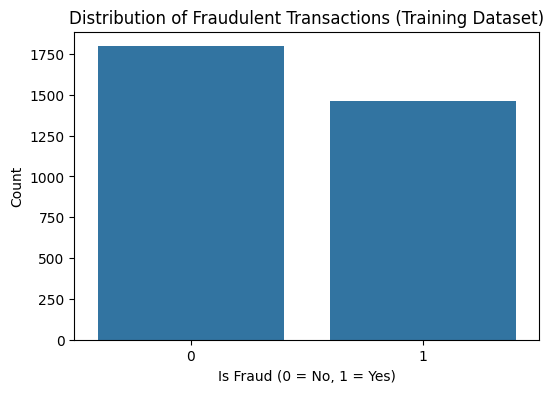

In [134]:
# Distribution of the target variable ('is_fraud') in the training dataset
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Distribution of Fraudulent Transactions (Training Dataset)')
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

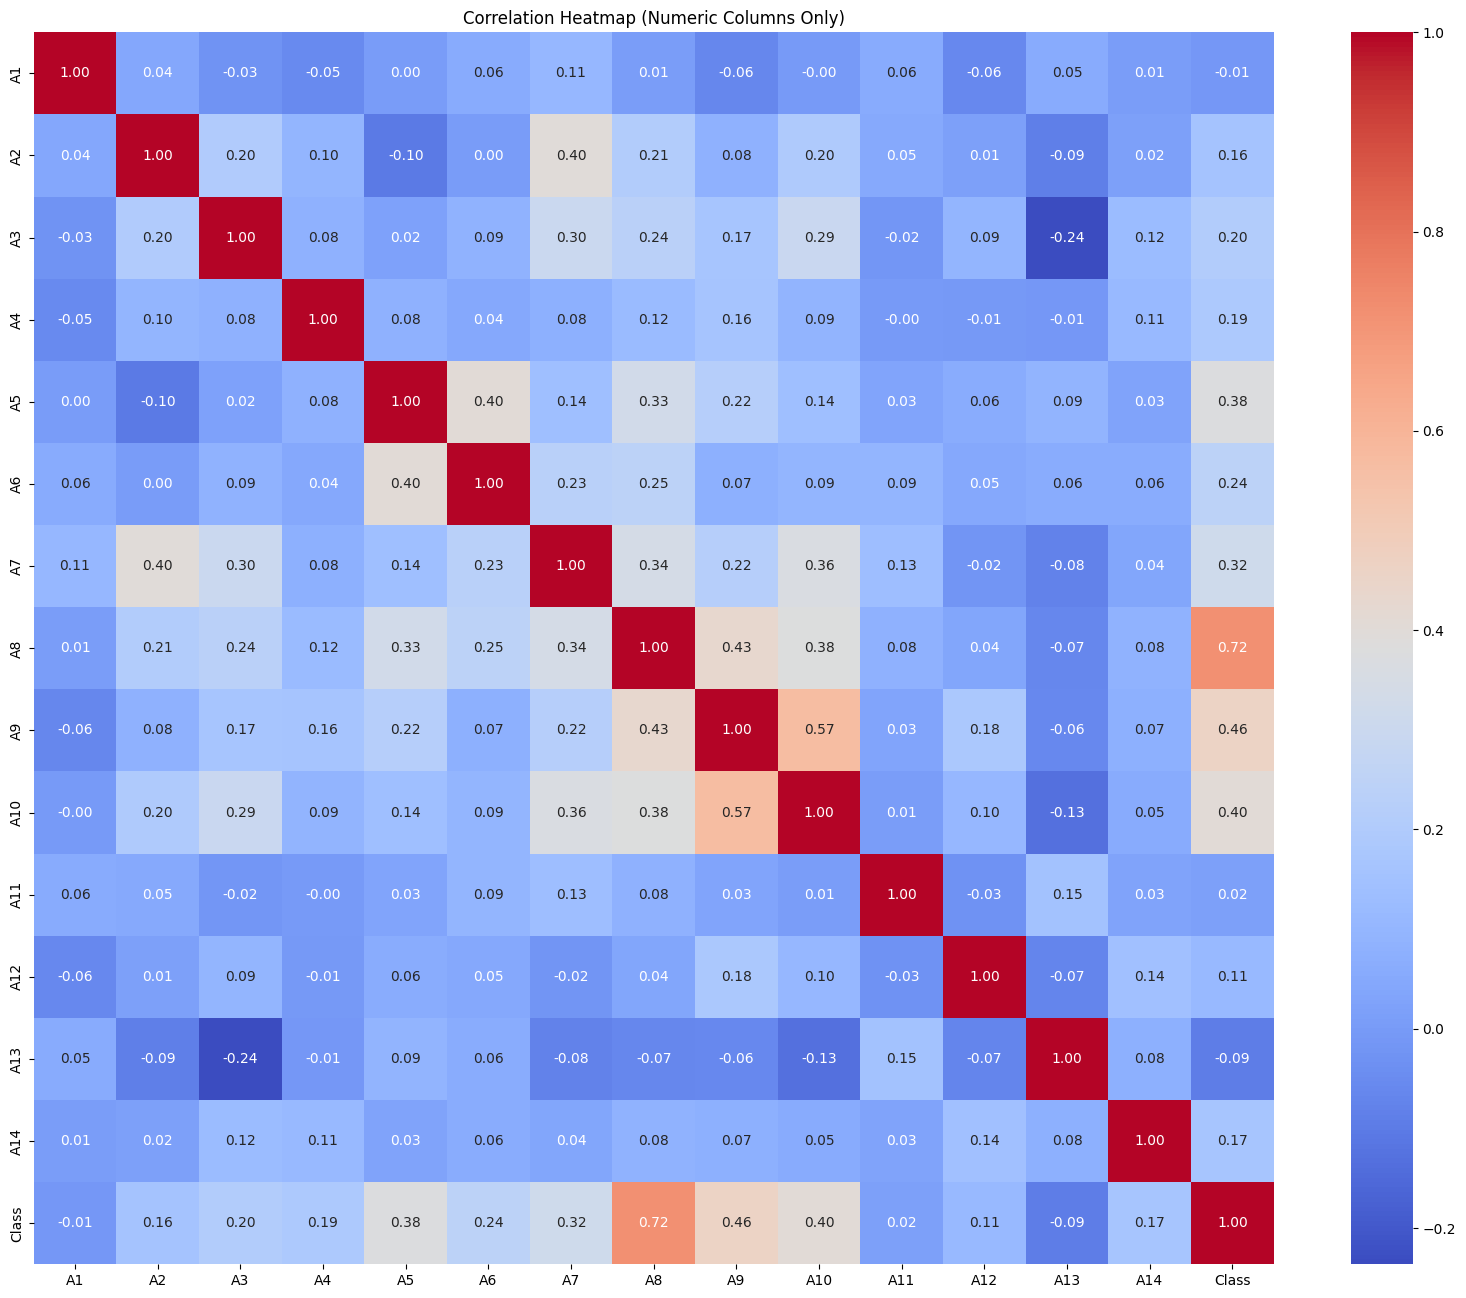

In [135]:
# Select only numeric columns for correlation analysis
numeric_data = df.select_dtypes(include=[np.number])

# Compute the correlation matrix
correlation_matrix = numeric_data.corr()

# Plot the heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Columns Only)')
plt.show()

In [136]:
data.X_train

array([[1.00000000e+00, 1.00300752e-01, 6.55357143e-02, ...,
        5.00000000e-01, 5.00000000e-02, 1.50000000e-03],
       [1.00000000e+00, 9.47368421e-01, 7.96071429e-01, ...,
        5.00000000e-01, 0.00000000e+00, 1.09000000e-03],
       [0.00000000e+00, 6.27067669e-02, 1.92857143e-02, ...,
        5.00000000e-01, 4.00000000e-02, 5.00000000e-05],
       ...,
       [1.00000000e+00, 1.60451128e-01, 4.40535714e-01, ...,
        5.00000000e-01, 6.00000000e-02, 0.00000000e+00],
       [0.00000000e+00, 4.07218045e-01, 3.57142857e-01, ...,
        5.00000000e-01, 1.45000000e-02, 8.37000000e-03],
       [1.00000000e+00, 5.72631579e-01, 1.07142857e-01, ...,
        5.00000000e-01, 9.00000000e-02, 4.00000000e-05]])

In [137]:
X

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
0,1,41.17,1.250,1,9,4,0.250,0,0,0,0,2,0,196
1,1,40.92,0.835,2,1,1,0.000,1,0,0,0,2,130,2
2,1,56.58,18.500,2,2,5,15.000,1,1,17,1,2,0,1
3,1,27.25,1.665,2,13,8,5.085,1,1,9,0,2,399,828
4,0,47.42,3.000,2,14,4,13.875,1,1,2,1,2,519,1705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3252,1,38.17,10.125,2,14,4,2.500,1,1,6,0,2,520,197
3253,1,67.75,5.500,2,10,9,13.000,1,1,1,1,2,0,1
3254,1,21.83,11.000,2,14,4,0.290,1,1,6,0,2,121,1
3255,0,27.67,1.500,2,7,4,2.000,1,0,0,0,1,368,1


## Initializing The BBOA Algorithm and Feature Selection Model

In [138]:
# ------------ Updated BBOA Feature Selector ---------------- #

class BBOAFeatureSelector:
    def __init__(self, n_agents=20, max_iter=30, exploration_rate=0.3, classifier=None,
                 cv_folds=5, save_dir="./bboa_results", random_state=42):
        self.n_agents = n_agents
        self.max_iter = max_iter
        self.exploration_rate = exploration_rate
        self.classifier = classifier if classifier else LogisticRegression()
        self.cv_folds = cv_folds
        self.save_dir = save_dir
        self.random_state = random_state
        np.random.seed(self.random_state)
        
        # Store fitness evolution
        self.fitness_curve = []

        # Create save directory
        os.makedirs(self.save_dir, exist_ok=True)

    def _initialize_population(self, n_features):
        return np.random.randint(0, 2, size=(self.n_agents, n_features))

    def _fitness(self, X, y, agent):
        selected_indices = np.where(agent == 1)[0]
        if len(selected_indices) == 0:
            return 0

        X_selected = X[:, selected_indices]

        clf = clone(self.classifier)
        skf = StratifiedKFold(n_splits=self.cv_folds, shuffle=True, random_state=self.random_state)
        scores = cross_val_score(clf, X_selected, y, cv=skf, scoring="accuracy")
        
        acc = np.mean(scores)
        feature_penalty = len(selected_indices) / X.shape[1]
        fitness = acc * (1 - 0.1 * feature_penalty)
        return fitness

    def fit(self, X, y):
        n_features = X.shape[1]
        self.population = self._initialize_population(n_features)
        self.best_agent = None
        self.best_fitness = -np.inf

        for iter_no in range(self.max_iter):
            start_time = time.time()  # Start timing the epoch
            fitness_values = []
            for agent in self.population:
                fitness = self._fitness(X, y, agent)
                fitness_values.append(fitness)

                if fitness > self.best_fitness:
                    self.best_fitness = fitness
                    self.best_agent = agent.copy()

            self.fitness_curve.append(self.best_fitness)

            # Update population
            new_population = []
            for agent in self.population:
                new_agent = agent.copy()

                if np.random.rand() < self.exploration_rate:
                    flip_index = np.random.randint(0, n_features)
                    new_agent[flip_index] = 1 - new_agent[flip_index]
                else:
                    move_indices = np.random.choice(n_features, size=int(0.3 * n_features), replace=False)
                    for idx in move_indices:
                        new_agent[idx] = self.best_agent[idx]

                new_population.append(new_agent)

            self.population = np.array(new_population)
            
            # Calculate elapsed time
            elapsed_time = time.time() - start_time

            print(f"Iteration {iter_no+1}/{self.max_iter}, Best Fitness: {self.best_fitness:.4f}, Time: {elapsed_time:.2f}s")

        self._plot_fitness_curve()
        self._save_best_agent()

    def transform(self, X):
        selected_indices = np.where(self.best_agent == 1)[0]
        return X[:, selected_indices]

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

    def get_selected_indices(self):
        return np.where(self.best_agent == 1)[0]

    def _plot_fitness_curve(self):
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(self.fitness_curve)+1), self.fitness_curve, marker="o")
        plt.title("BBOA Feature Selection - Fitness Evolution")
        plt.xlabel("Iteration")
        plt.ylabel("Best Fitness Score")
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(os.path.join(self.save_dir, "fitness_curve.png"))
        plt.show()

    def _save_best_agent(self):
        np.save(os.path.join(self.save_dir, "best_agent.npy"), self.best_agent)
        summary = {
            "selected_features_count": int(np.sum(self.best_agent)),
            "total_features": int(len(self.best_agent)),
            "best_fitness_score": float(self.best_fitness),
            "cv_folds": self.cv_folds
        }
        with open(os.path.join(self.save_dir, "summary.json"), "w") as f:
            json.dump(summary, f, indent=4)

Iteration 1/30, Best Fitness: 0.8346, Time: 0.20s
Iteration 2/30, Best Fitness: 0.8346, Time: 0.18s
Iteration 3/30, Best Fitness: 0.8469, Time: 0.17s
Iteration 4/30, Best Fitness: 0.8469, Time: 0.16s
Iteration 5/30, Best Fitness: 0.8469, Time: 0.15s
Iteration 6/30, Best Fitness: 0.8530, Time: 0.13s
Iteration 7/30, Best Fitness: 0.8530, Time: 0.14s
Iteration 8/30, Best Fitness: 0.8530, Time: 0.13s
Iteration 9/30, Best Fitness: 0.8530, Time: 0.13s
Iteration 10/30, Best Fitness: 0.8530, Time: 0.13s
Iteration 11/30, Best Fitness: 0.8530, Time: 0.13s
Iteration 12/30, Best Fitness: 0.8530, Time: 0.12s
Iteration 13/30, Best Fitness: 0.8530, Time: 0.12s
Iteration 14/30, Best Fitness: 0.8530, Time: 0.12s
Iteration 15/30, Best Fitness: 0.8530, Time: 0.12s
Iteration 16/30, Best Fitness: 0.8530, Time: 0.11s
Iteration 17/30, Best Fitness: 0.8530, Time: 0.12s
Iteration 18/30, Best Fitness: 0.8530, Time: 0.12s
Iteration 19/30, Best Fitness: 0.8530, Time: 0.11s
Iteration 20/30, Best Fitness: 0.8530, T

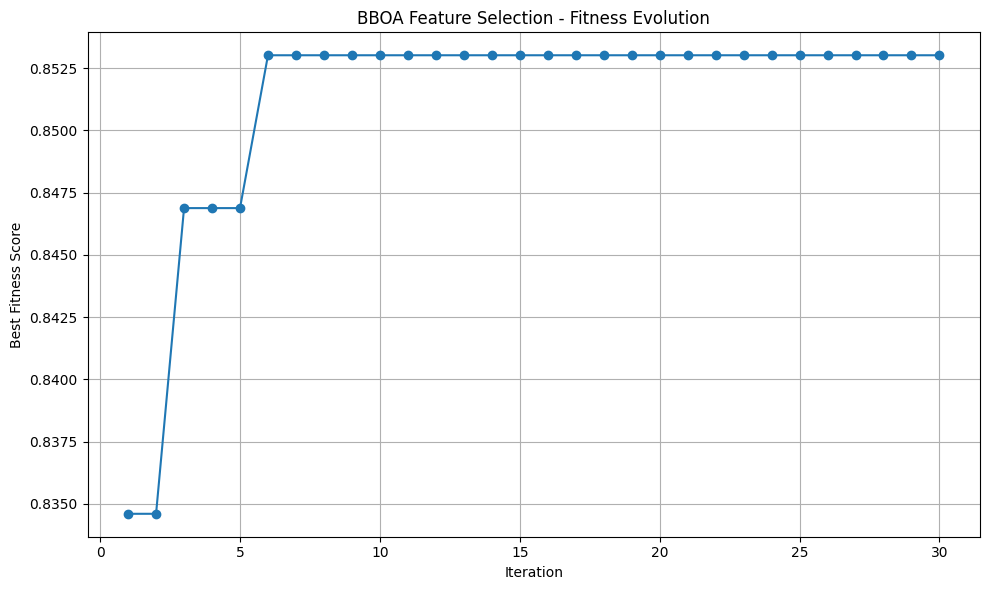

Original features: 14
Selected features: 1


In [139]:
# Initialize BBOA Feature Selector
bboa_selector = BBOAFeatureSelector(
    n_agents=20,
    max_iter=30,
    exploration_rate=0.3,
    classifier=LogisticRegression(),
    cv_folds=5,
    save_dir="./bboa_results",
    random_state=42
)

# Fit and transform your data
X_train_selected = bboa_selector.fit_transform(data.X_train, data.y_train)

# Reduce X_test as well
selected_indices = bboa_selector.get_selected_indices()
X_test_selected = data.X_test[:, selected_indices]

print(f"Original features: {data.X_train.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

In [140]:
print(f"Original Dataset: {data.X_train.shape}")
print(f"Selected dataset: {X_test_selected.shape}")

Original Dataset: (2279, 14)
Selected dataset: (978, 1)


In [141]:
X_train_selected.shape[1]

1

In [142]:
X_test_selected

array([[0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],

### Spiking Neural Network (SNN) Definition and Training ###

In [143]:
# --------- Simple SNN Model for Classification ------------- #

# -------- Surrogate Function --------
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        return (input >= 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        grad_input = grad_output.clone()
        # surrogate gradient: d(ReLU)/dx (approximate)
        surrogate_grad = torch.sigmoid(5 * input) * (1 - torch.sigmoid(5 * input))
        return grad_input * surrogate_grad

surrogate_spike_fn = SurrogateSpike.apply

# -------- Updated SNNLayer --------
class SNNLayer(nn.Module):
    def __init__(self, in_features, out_features, threshold=1.0, decay=0.9):
        super(SNNLayer, self).__init__()
        self.fc = nn.Linear(in_features, out_features)
        self.threshold = threshold
        self.decay = decay
        self.mem = None

    def forward(self, x):
        if self.mem is None:
            self.mem = torch.zeros(x.size(0), self.fc.out_features, device=x.device)

        current = self.fc(x)
        self.mem = self.mem * self.decay + current
        spike = surrogate_spike_fn(self.mem - self.threshold)
        self.mem = self.mem * (1 - spike)  # reset after spike
        return spike

    def reset(self):
        self.mem = None

# -------- Updated SNNClassifier --------
class SNNClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, threshold=1.0):
        super(SNNClassifier, self).__init__()
        self.snn1 = SNNLayer(input_dim, hidden_dim, threshold=threshold)
        self.snn2 = SNNLayer(hidden_dim, output_dim, threshold=threshold)

    def forward(self, x, time_steps=20):
        out_spikes = torch.zeros(x.size(0), self.snn2.fc.out_features, device=x.device)
        for t in range(time_steps):
            spike1 = self.snn1(x)
            spike2 = self.snn2(spike1)
            out_spikes += spike2
        return out_spikes  # output spike counts (higher means more confident)

    def reset(self):
        self.snn1.reset()
        self.snn2.reset()

# -------- Updated SNNTrainer --------
class SNNTrainer:
    def __init__(self, model, lr=1e-3, epochs=50, batch_size=32, device=None):
        self.model = model
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)
        self.losses = []

    def fit(self, X_train, y_train):
        X_train = torch.tensor(X_train, dtype=torch.float32)
        y_train = torch.tensor(y_train, dtype=torch.long)

        dataset = torch.utils.data.TensorDataset(X_train, y_train)
        loader = torch.utils.data.DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(self.epochs):
            
            start_time = time.time()
            
            self.model.train()
            epoch_loss = 0
            for xb, yb in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)

                self.model.reset()
                out = self.model(xb)

                loss = criterion(out, yb)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            avg_epoch_loss = epoch_loss / len(loader)
            self.losses.append(avg_epoch_loss)

             # Calculate elapsed time
            elapsed_time = time.time() - start_time

            print(f"Epoch {epoch+1}/{self.epochs}, Loss: {avg_epoch_loss:.4f}, Time: {elapsed_time:.2f}s")

    def plot_training_loss(self):
        plt.figure(figsize=(8,6))
        plt.plot(self.losses, label="Training Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Curve")
        plt.legend()
        plt.grid()
        plt.show()

    def evaluate(self, X_test, y_test):
        self.model.eval()
        X_test = torch.tensor(X_test, dtype=torch.float32).to(self.device)
        y_test = torch.tensor(y_test, dtype=torch.long).to(self.device)
    
        self.model.reset()
        out = self.model(X_test)  # raw logits or probabilities
        preds = torch.argmax(out, dim=1)
    
        y_true = y_test.cpu().numpy()
        y_pred = preds.cpu().numpy()
    
        # Metrics
        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, average="weighted")
        recall = recall_score(y_true, y_pred, average="weighted")
        f1 = f1_score(y_true, y_pred, average="weighted")
    
        # MCC
        mcc = matthews_corrcoef(y_true, y_pred)
    
        # AUC-ROC Score (binary or one-vs-rest)
        if out.shape[1] == 2:
            probs = torch.softmax(out, dim=1)[:, 1].detach().cpu().numpy()
            auc_roc = roc_auc_score(y_true, probs)
            
            # Plot ROC curve
            fpr, tpr, _ = roc_curve(y_true, probs)
            plt.figure()
            plt.plot(fpr, tpr, label=f'AUC = {auc_roc:.4f}')
            plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title('ROC Curve')
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            auc_roc = roc_auc_score(y_true, out.detach().cpu().numpy(), multi_class='ovr', average='weighted')
    
        # Print Metrics
        print("\nClassification Report:\n", classification_report(y_true, y_pred))
        print("Accuracy:", acc)
        print("Precision:", precision)
        print("Recall:", recall)
        print("F1 Score:", f1)
        print("MCC:", mcc)
        print("AUC-ROC Score:", auc_roc)
    
        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    
        return acc, precision, recall, f1, mcc, auc_roc

    def save_model(self, path="./snn_model.pth"):
        torch.save(self.model.state_dict(), path)

    def load_model(self, path="./snn_model.pth"):
        self.model.load_state_dict(torch.load(path, map_location=self.device))

Epoch 1/30, Loss: 0.4257, Time: 0.33s
Epoch 2/30, Loss: 0.4222, Time: 0.33s
Epoch 3/30, Loss: 0.4001, Time: 0.33s
Epoch 4/30, Loss: 0.4204, Time: 0.32s
Epoch 5/30, Loss: 0.4058, Time: 0.33s
Epoch 6/30, Loss: 0.4091, Time: 0.33s
Epoch 7/30, Loss: 0.4203, Time: 0.33s
Epoch 8/30, Loss: 0.4214, Time: 0.32s
Epoch 9/30, Loss: 0.4413, Time: 0.32s
Epoch 10/30, Loss: 0.4027, Time: 0.33s
Epoch 11/30, Loss: 0.4061, Time: 0.32s
Epoch 12/30, Loss: 0.4240, Time: 0.33s
Epoch 13/30, Loss: 0.4058, Time: 0.33s
Epoch 14/30, Loss: 0.4143, Time: 0.33s
Epoch 15/30, Loss: 0.4188, Time: 0.32s
Epoch 16/30, Loss: 0.4012, Time: 0.33s
Epoch 17/30, Loss: 0.4116, Time: 0.33s
Epoch 18/30, Loss: 0.4144, Time: 0.33s
Epoch 19/30, Loss: 0.3983, Time: 0.34s
Epoch 20/30, Loss: 0.4078, Time: 0.33s
Epoch 21/30, Loss: 0.4120, Time: 0.33s
Epoch 22/30, Loss: 0.4112, Time: 0.33s
Epoch 23/30, Loss: 0.4140, Time: 0.33s
Epoch 24/30, Loss: 0.4100, Time: 0.33s
Epoch 25/30, Loss: 0.4125, Time: 0.32s
Epoch 26/30, Loss: 0.4099, Time: 0

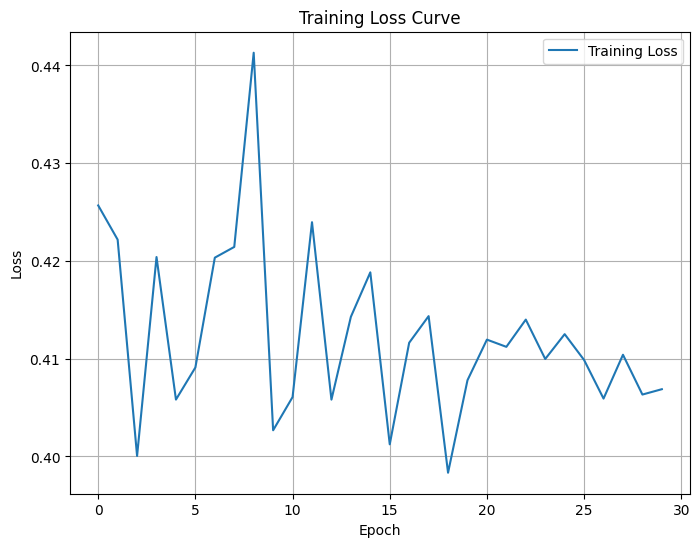

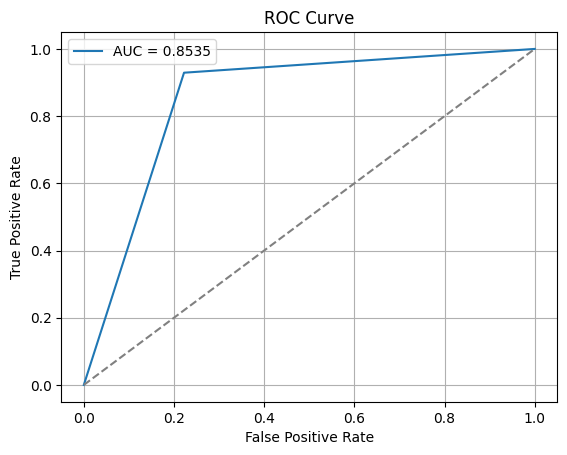


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.78      0.85       540
           1       0.77      0.93      0.84       438

    accuracy                           0.85       978
   macro avg       0.85      0.85      0.85       978
weighted avg       0.86      0.85      0.85       978

Accuracy: 0.84560327198364
Precision: 0.8600696707763238
Recall: 0.84560327198364
F1 Score: 0.8457900692359208
MCC: 0.7052785983366255
AUC-ROC Score: 0.8535007610350077


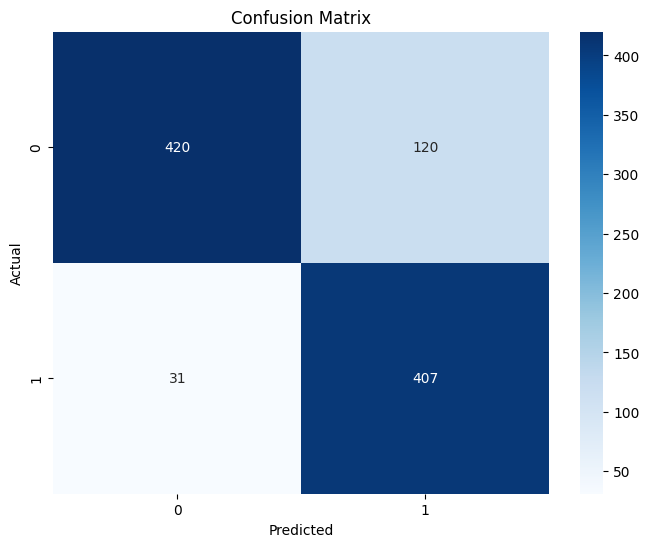

In [144]:
# Initialize
input_dim = X_train_selected.shape[1]
hidden_dim = 128
output_dim = len(np.unique(data.y_train))  # number of classes

snn_model = SNNClassifier(input_dim, hidden_dim, output_dim)

# Train
trainer = SNNTrainer(snn_model, lr=0.001, epochs=30, batch_size=32)
trainer.fit(X_train_selected, data.y_train)

# Plot Training Loss
trainer.plot_training_loss()

# Evaluate
trainer.evaluate(X_test_selected, data.y_test)

# Save Model
trainer.save_model("./bboa_selected_snn_model.pth")